<a href="https://colab.research.google.com/github/Wanyiri9dave/crash-dataset-analysis/blob/main/crash_severity_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
# Import necesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
!pip install category_encoders
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc

In [75]:
df = pd.read_csv('/content/chicago_2019_2022_cleaned.csv')
df.head()

,id,crash_date,crash_time,town,city,state,country,total_injured,total_killed,injury_incapacitated,...,sunset,moonphase,hour,weekday,month,is_night,season,time_period,region_cluster,weather_severity
0,200319661,2019-07-18,10:35:00,harwood heights,chicago,illinois,usa,0,0,0,...,20:23:09,0.56,10,Thursday,7,0,Summer,morning,2,28.118429
1,200320894,2019-07-21,16:00:00,cragin,chicago,illinois,usa,0,0,0,...,20:20:12,0.66,16,Sunday,7,0,Summer,afternoon,4,21.512849
2,200320909,2019-07-21,16:45:00,cragin,chicago,illinois,usa,0,0,0,...,20:20:10,0.66,16,Sunday,7,0,Summer,afternoon,4,21.693349
3,200320970,2019-07-21,23:18:00,altgeld gardens,chicago,illinois,usa,0,0,0,...,20:18:09,0.69,23,Sunday,7,1,Summer,night,7,19.848349
4,200320991,2019-07-22,04:10:00,cragin,chicago,illinois,usa,1,0,0,...,20:19:19,0.69,4,Monday,7,1,Summer,night,4,25.128349


In [76]:
df.columns

Index(['id', 'crash_date', 'crash_time', 'town', 'city', 'state', 'country',
       'total_injured', 'total_killed', 'injury_incapacitated',
       'injury_non_incapacitated', 'most_severe_injury', 'crash_type',
       'contributory_cause', 'sec_contributory_cause', 'num_vehicles_in_crash',
       'crash_hit_and_run', 'crash_severity', 'traffic_control_device',
       'traffic_control_device_condition', 'road_defect', 'lattitude',
       'longitude', 'days_tempmax', 'days_tempmin', 'days_temp',
       'days_feelslikemax', 'days_feelslikemin', 'days_feelslike', 'days_dew',
       'days_humidity', 'days_precip', 'days_precipprob', 'days_precipcover',
       'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust',
       'days_windspeed', 'days_winddir', 'days_pressure', 'days_cloudcover',
       'days_visibility', 'days_uvindex', 'days_conditions', 'days_moonphase',
       'temp', 'feelslike', 'humidity', 'dew', 'precip', 'precipprob', 'snow',
       'snowdepth', 'precip_type',

In [109]:
data = df.drop(['id', 'crash_date', 'crash_time', 'town', 'city', 'state', 'country',
       'total_injured', 'total_killed', 'injury_incapacitated',
       'injury_non_incapacitated', 'most_severe_injury',
       'sec_contributory_cause',
       'crash_hit_and_run','traffic_control_device',
       'traffic_control_device_condition', 'lattitude',
       'longitude', 'days_tempmax', 'days_tempmin', 'days_temp',
       'days_feelslikemax', 'days_feelslikemin', 'days_feelslike', 'days_dew',
       'days_humidity', 'days_precip', 'days_precipprob', 'days_precipcover',
       'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust',
       'days_windspeed', 'days_winddir', 'days_pressure', 'days_cloudcover',
       'days_visibility', 'days_uvindex', 'days_conditions', 'days_moonphase',
       'feelslike', 'humidity', 'dew', 'precip', 'precipprob', 'snow',
       'snowdepth', 'precip_type', 'windgust', 'windspeed', 'winddir',
       'pressure', 'visibility', 'cloudcover','sunrise',
       'sunset', 'moonphase','is_night','month'],axis=1)

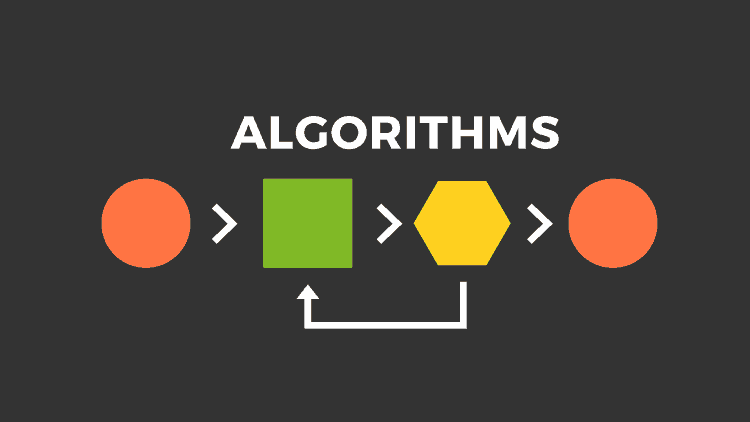

* Predicting crash severity depends on many factors interacting together, such as weather, time, and road conditions. These relationships are complex and not easily captured using simple analysis techniques. Machine learning models were used because they can identify patterns and relationships in large datasets and provide more accurate predictions than traditional methods.

## Baseline Logisitic Regression Model

---



* A baseline logistic regression model will serve as the starting point. Logistic regression is well-suited for binary classification tasks and provides:

    * Clear interpretability through feature coefficients.
    * Insight into the direction and magnitude of feature effects.
    * A benchmark for evaluating more complex models.

In [110]:
# Prepare Features and Target

x = data[['crash_type', 'contributory_cause', 'num_vehicles_in_crash','road_defect', 'temp', 'conditions', 'hour',
       'weekday', 'season', 'time_period', 'region_cluster',
       'weather_severity']]
y = data[['crash_severity']]

In [81]:
# Split into Training and Testing (80/20)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [82]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64638 entries, 25807 to 15795
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   crash_type             64638 non-null  object 
 1   contributory_cause     64638 non-null  object 
 2   num_vehicles_in_crash  64638 non-null  int64  
 3   road_defect            64638 non-null  object 
 4   temp                   64638 non-null  float64
 5   conditions             64638 non-null  object 
 6   hour                   64638 non-null  int64  
 7   weekday                64638 non-null  object 
 8   season                 64638 non-null  object 
 9   time_period            64638 non-null  object 
 10  region_cluster         64638 non-null  int64  
 11  weather_severity       64638 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 6.4+ MB


In [83]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16160 entries, 52809 to 20768
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   crash_type             16160 non-null  object 
 1   contributory_cause     16160 non-null  object 
 2   num_vehicles_in_crash  16160 non-null  int64  
 3   road_defect            16160 non-null  object 
 4   temp                   16160 non-null  float64
 5   conditions             16160 non-null  object 
 6   hour                   16160 non-null  int64  
 7   weekday                16160 non-null  object 
 8   season                 16160 non-null  object 
 9   time_period            16160 non-null  object 
 10  region_cluster         16160 non-null  int64  
 11  weather_severity       16160 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.6+ MB


In [84]:
# Target Encoding for high cardinality features.

high_card_cols = ['crash_type', 'contributory_cause']

target_encoder = ce.TargetEncoder(cols=high_card_cols)
X_train_te = target_encoder.fit_transform(X_train, y_train)
X_test_te = target_encoder.transform(X_test)

In [85]:
# Categorical Encoding for low cardinality columns.

cats = ['road_defect', 'conditions', 'weekday', 'season', 'time_period']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train_te[cats])
X_test_ohe = ohe.transform(X_test_te[cats])


In [86]:
# Convert to DataFrame to concatenate later

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cats), index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cats), index=X_test.index)


In [87]:
# Drop original low-cardinality columns and concatenate encoded ones
X_train_final = pd.concat([X_train_te.drop(columns=cats), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test_te.drop(columns=cats), X_test_ohe_df], axis=1)

In [88]:
# SCALE the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [89]:
# Train the Model

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [90]:
# Evaluate Model Perfomance

y_pred = log_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.21      0.31      5934
           1       0.66      0.91      0.77     10226

    accuracy                           0.65     16160
   macro avg       0.62      0.56      0.54     16160
weighted avg       0.63      0.65      0.60     16160



* This baseline model achieves 65% accuracy, showing moderate performance overall.

    * It performs well on the majority class (Class 1), correctly identifying most cases.

    * However, it performs poorly on the minority class (Class 0), missing a large portion of those cases.

* The model provides a reasonable starting point, but it is imbalanced and biased toward the more frequent class.

## Random Forest Classifier

---



* A Random Forest is an ensemble model, meaning it combines many individual decision trees to make a final prediction.

* By combining multiple trees, it averages out mistakes,this often leads to more stable and slightly higher performance.

In [91]:
from sklearn.ensemble import RandomForestClassifier


In [92]:
# Encode high-cardinality categorical features

high_card_cols = ['crash_type', 'contributory_cause']
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

for col in high_card_cols:
    le = LabelEncoder()
    X_train_rf[col] = le.fit_transform(X_train_rf[col])
    X_test_rf[col] = le.transform(X_test_rf[col])

low_card_cols = ['road_defect', 'conditions', 'weekday', 'season', 'time_period']
for col in low_card_cols:
    le = LabelEncoder()
    X_train_rf[col] = le.fit_transform(X_train_rf[col])
    X_test_rf[col] = le.transform(X_test_rf[col])

In [93]:
# Random Forest BEFORE SMOTE
rf_before = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_before.fit(X_train_rf, y_train)
y_pred_before = rf_before.predict(X_test_rf)

print("=== Random Forest BEFORE SMOTE ===")
print(classification_report(y_test, y_pred_before))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


=== Random Forest BEFORE SMOTE ===
              precision    recall  f1-score   support

           0       0.52      0.31      0.39      5934
           1       0.68      0.83      0.75     10226

    accuracy                           0.64     16160
   macro avg       0.60      0.57      0.57     16160
weighted avg       0.62      0.64      0.62     16160



* The model achieves 64% accuracy, performing well on the majority class (Class 1) with high recall (83%), meaning it correctly identifies most of those cases. However, it struggles with the minority class (Class 0), capturing only 31% of those instances.

In [94]:
# Apply SMOTE on training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rf, y_train)

* Even though a Random Forest is powerful, it does not automatically fix class imbalance.

* Adding SMOTE helps the model better identify rare but important cases, improving decision-making where missing those cases would be costly.

In [95]:
# Random Forest AFTER SMOTE

rf_after = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_after.fit(X_train_smote, y_train_smote)
y_pred_after = rf_after.predict(X_test_rf)

print("=== Random Forest AFTER SMOTE ===")
print(classification_report(y_test, y_pred_after))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


=== Random Forest AFTER SMOTE ===
              precision    recall  f1-score   support

           0       0.48      0.49      0.49      5934
           1       0.70      0.69      0.70     10226

    accuracy                           0.62     16160
   macro avg       0.59      0.59      0.59     16160
weighted avg       0.62      0.62      0.62     16160



* Random Forest better captures minor crashes (class 0), which Logistic Regression struggled with, thanks to its ability to model non-linear relationships and interactions.

* After applying SMOTE, the model’s accuracy slightly drops to 62%, but performance becomes more balanced. Recall for Class 0 improves significantly to 49%, while recall for Class 1 decreases to 69% - The model becomes more balanced and fair, improving detection of previously missed cases at the cost of a small reduction in overall accuracy.

* Accuracy alone is not sufficient here; macro F1 or per-class recall is more informative due to imbalance.

## XGBoost

---



* XGBoost (Extreme Gradient Boosting) is an advanced machine learning model that uses a technique called boosting.

* Instead of many independent trees (like Random Forest), XGBoost builds a chain of trees where each one learns from past mistakes.

* XGBoost provides more accurate and refined predictions by continuously improving on its mistakes, making it especially useful for complex, real-world problems where patterns are not straightforward.

In [96]:
from xgboost import XGBClassifier

In [97]:
# Encode Categorical Features.

high_card_cols = ['crash_type', 'contributory_cause']
low_card_cols = ['road_defect', 'conditions', 'weekday', 'season', 'time_period']

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in high_card_cols + low_card_cols:
    le = LabelEncoder()
    X_train_xgb[col] = le.fit_transform(X_train_xgb[col])
    X_test_xgb[col] = le.transform(X_test_xgb[col])


In [98]:
# Handle class imbalance

# ratio = negative / positive

scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum()).iloc[0]

In [104]:
# Train XGboost

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train_xgb, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_xgb)

print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:01:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.48      0.65      0.56      5934
           1       0.75      0.60      0.66     10226

    accuracy                           0.62     16160
   macro avg       0.62      0.62      0.61     16160
weighted avg       0.65      0.62      0.62     16160



* Improved balance between classes

    * Minority class recall jumps from 49% (RF+SMOTE) to 65%, meaning the model now detects most of the previously missed Class 0 cases.

    * Majority class recall decreases slightly (from 69% to 60%), but the model is more balanced overall.

* Higher F1-score for minority class

    * F1 of 0.56 for Class 0 indicates better trade-off between precision and recall for the minority class.

* Weighted average F1: 0.62

    * Reflects overall improvement in predictive reliability across both classes.

* Compared to the baseline and Random Forest, XGBoost is the most accurate and balanced model so far, offering better detection of critical minority cases while maintaining reasonable overall accuracy.

### ROC Curve

---



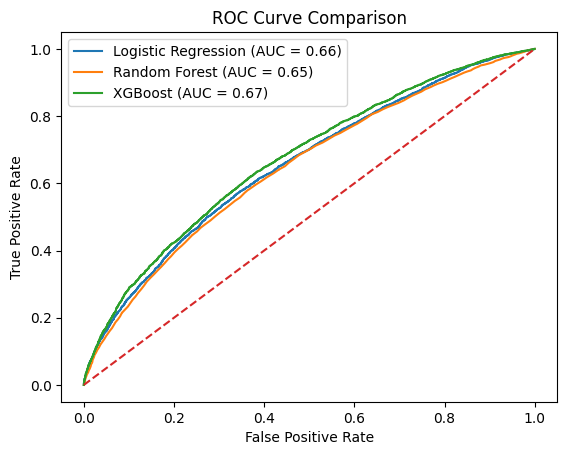

In [100]:
plt.figure()

y_probs_lr = log_model.predict_proba(X_test_scaled)[:, 1]
y_probs_rf = rf_before.predict_proba(X_test_rf)[:, 1]
y_probs_rf_smote = rf_after.predict_proba(X_test_rf)[:, 1]
y_probs_xgb = xgb.predict_proba(X_test_xgb)[:, 1]
# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

* The models perform better than random guessing, but not strongly enough for highly reliable predictions. This means the system can support decisions, but should not be the sole basis for critical actions.

### Using K-Cross Validation

---



In [103]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation (use macro F1 for imbalance)
scores = cross_val_score(
    xgb,
    X_train_xgb,
    y_train,
    cv=skf,
    scoring='f1_macro'
)

print("F1 Macro scores:", scores)
print("Mean F1 Macro:", np.mean(scores))

F1 Macro scores: [0.60924927 0.6124679  0.61158675 0.59997524 0.60708318]
Mean F1 Macro: 0.6080724689970636


* The XGBoost model achieved a mean macro F1-score of approximately 0.61 using 5-fold stratified cross-validation, with minimal variation across folds. This indicates that the model is stable and generalizes well to unseen data. Compared to baseline models, XGBoost provides the best balance between classes, particularly improving the detection of minority class (minor crashes).

* XGBoost was selected as the final model due to its superior macro F1-score and balanced performance across classes. The model significantly improved the detection of minority class (minor crashes), addressing class imbalance and providing more reliable predictions for real-world applications.

### Feature Importance



---



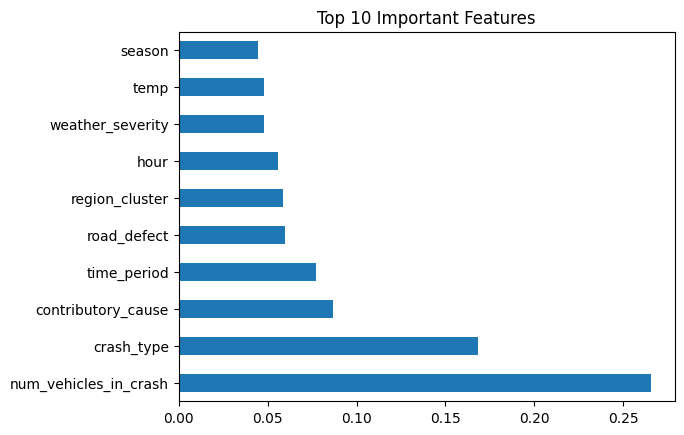

In [105]:

importance = pd.Series(xgb.feature_importances_, index=X_train_xgb.columns)
importance = importance.sort_values(ascending=False)

importance.head(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

* The analysis shows that crash-specific factors are the primary drivers of injury severity, with the number of vehicles involved and type of crash having the greatest impact. This indicates that multi-vehicle collisions and certain crash types pose significantly higher risk, making them key targets for intervention.

    * From a business and policy perspective, this suggests that resources should be prioritized toward preventing high-impact crash scenarios. For example:

    * Investing in traffic control measures (e.g., better signaling, lane management) to reduce multi-vehicle collisions

    * Enhancing road safety enforcement around high-risk driving behaviors linked to specific crash types

* Moderate factors such as contributory causes (e.g., human error) and time of day highlight opportunities for targeted awareness campaigns and enforcement during high-risk periods.

* In contrast, weather and seasonal conditions have relatively low influence, suggesting that broad investments in weather-related interventions may yield lower returns compared to focusing on crash dynamics and driver behavior.

### Comparison Table

---



In [106]:

results = {
    "Logistic Regression": {
        "Accuracy": 0.65,
        "Class 0 Recall": 0.21,
        "Class 1 Recall": 0.91,
        "Macro F1": 0.54
    },
    "Random Forest": {
        "Accuracy": 0.64,
        "Class 0 Recall": 0.31,
        "Class 1 Recall": 0.84,
        "Macro F1": 0.57
    },
    "RF + SMOTE": {
        "Accuracy": 0.62,
        "Class 0 Recall": 0.49,
        "Class 1 Recall": 0.69,
        "Macro F1": 0.59
    },
    "XGBoost": {
        "Accuracy": 0.62,
        "Class 0 Recall": 0.65,
        "Class 1 Recall": 0.60,
        "Macro F1": 0.61
    }
}

df_results = pd.DataFrame(results).T

In [108]:
df_results.style.background_gradient(cmap="Blues")

,Accuracy,Class 0 Recall,Class 1 Recall,Macro F1
Logistic Regression,0.650000,0.210000,0.910000,0.540000
Random Forest,0.640000,0.310000,0.840000,0.570000
RF + SMOTE,0.620000,0.490000,0.690000,0.590000
XGBoost,0.620000,0.650000,0.600000,0.610000


* The table above compares model performance across key metrics. While Logistic Regression achieved high recall for major crashes, it failed to capture minor crashes. Random Forest improved balance, and the use of SMOTE further enhanced minority class detection. XGBoost achieved the best overall performance, with the highest macro F1-score and the most balanced recall across classes.

# **Results**

---



* Model performance was evaluated using macro F1-score, as it provides a balanced measure of performance across both classes in the presence of class imbalance. Accuracy alone was not sufficient, as it can be misleading when one class dominates.

* The XGBoost model achieved the best performance with a macro F1-score of approximately 0.61, outperforming Logistic Regression and Random Forest. Notably, it significantly improved recall for the minority class (minor crashes), increasing it from 0.21 in the baseline model to 0.65. This indicates a substantial improvement in the model’s ability to detect underrepresented outcomes.

* Cross-validation confirmed the stability of the model, with a mean macro F1-score of 0.61 and low variance across folds, suggesting consistent generalization.

# **Limitations**

---



* Despite improvements, the model still shows a trade-off between detecting minor and major crashes. Increasing recall for minor crashes resulted in a slight decrease in performance for major crashes.

* Additionally, performance may vary across specific subsets of the data, such as rare crash types or uncommon weather conditions, where limited training examples reduce model reliability. High-cardinality categorical features, while informative, may also introduce noise and reduce generalization in certain cases.

* Furthermore, the model relies on historical data and does not account for external factors such as real-time traffic conditions or driver behavior, which may limit its predictive accuracy in real-world deployment.

# **Recommendations**

---



* The model can be used as a decision-support tool to identify high-risk conditions associated with severe crashes. Future improvements could include incorporating additional data sources such as real-time traffic or geographic features to enhance predictive performance.

* Further tuning and feature engineering may improve minority class performance, particularly through more advanced interaction features or ensemble methods.